In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/Sahdam/TS_Academy_Capstone_Project/refs/heads/main/Model_Data_set.csv"
df = pd.read_csv(url, parse_dates=["Date"], index_col="Date")
df.head()

,food_cpi,fuel_price,exchange_rate,basket_cost
Date,,,,
2017-01-31,221.4,148.70,305.20,17028.51
2017-02-28,225.8,149.80,305.31,17171.78
2017-03-31,230.8,149.39,306.40,17846.54
2017-04-30,235.5,149.87,306.05,18087.17
2017-05-31,241.5,150.69,305.54,18632.75


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

markdown---

### Basket Cost Seasonal Decomposition (Multiplicative)

**Observation**  
The multiplicative decomposition separates basket cost into three components: a dominant upward trend, a stable repeating seasonal pattern, and a residual that amplifies post-2023.

**Trend Component (orange)**  
- Flat and near-zero growth from 2017–2020, confirming basket cost was structurally stable in this period
- Gradual acceleration from 2020–2022 as COVID supply chain effects and pre-shock inflation built up
- Sharp exponential-style surge from mid-2023 onward, reaching ~₦100,000 by 2025
- The trend component smoothly captures the regime change — confirming the shock was a **permanent level shift**, not a temporary spike

**Seasonal Component (green)**  
- Oscillates consistently between **0.99 and 1.02** across the entire 2017–2026 period
- The pattern repeats identically every 12 months — confirming a **stable annual seasonality** (m=12)
- Seasonal amplitude is very small (~±1%) relative to the overall price level — meaning seasonality explains only a minor fraction of total price variation
- The consistency of the seasonal pattern across both the pre- and post-shock periods confirms that the shock did not distort the seasonal cycle — it only shifted the trend level

**Residual Component (red)**  
- Residuals remained tightly clustered around 1.0 (the neutral line) from 2017–2023 — confirming the model fits well in the stable period
- Post-2024, residuals become more volatile, oscillating between 0.93 and 1.06 — reflecting price volatility that the trend and seasonal components cannot fully explain
- The increased residual variance post-2023 is direct evidence of **heteroskedasticity** (non-constant variance)

**Modelling Implication**  
- The stable seasonal component confirms `m=12` and `D=1` (seasonal differencing) are appropriate in SARIMAX
- The increasing residual variance post-2023 justifies **GARCH modelling** on the residuals to capture time-varying volatility
- The smooth trend confirms shock dummies are needed to model the level shift, as the tr

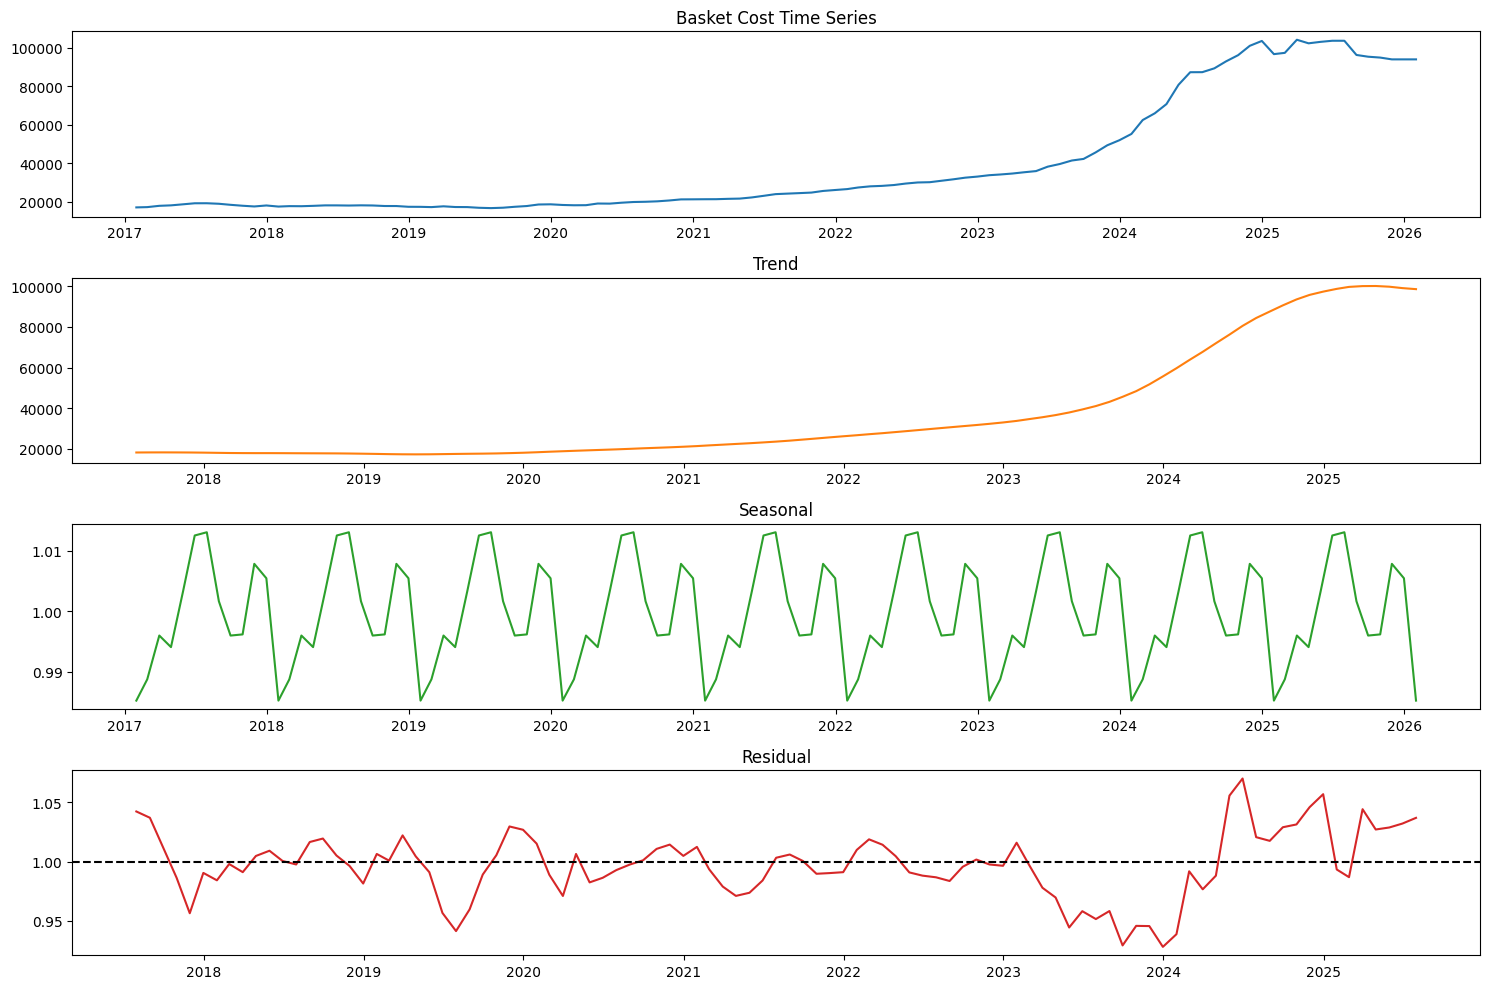

In [28]:
decompose_basket = seasonal_decompose(df["basket_cost"], model="mul", period=12)
trend = decompose_basket.trend
seasonal = decompose_basket.seasonal
residual = decompose_basket.resid

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

axes[0].plot(df["basket_cost"])
axes[0].set_title("Basket Cost Time Series")

axes[1].plot(trend, color="C1")
axes[1].set_title("Trend")

axes[2].plot(seasonal, color="C2")
axes[2].set_title("Seasonal")

axes[3].plot(residual, color="C3")
axes[3].set_title("Residual")
plt.axhline(1.0, linestyle="--", color="k")

plt.tight_layout()
plt.savefig('Basket_seasonal_decompose', dpi=150, bbox_inches='tight')
plt.show()

### Food CPI Seasonal Decomposition (Multiplicative)

**Observation**  
The decomposition reveals a consistently growing trend, a very weak but stable seasonal pattern, and residuals that are well-behaved pre-2023 but diverge sharply post-2024.

**Trend Component (orange)**  
- Unlike basket cost, the CPI Food trend shows **no flat period** — it has grown continuously since 2017 without pause
- Growth is smooth and accelerating — the curve is concave upward throughout, steepening noticeably from 2022 onward
- The trend reaches ~1,200 by late 2025, closely tracking the original series — confirming the trend component captures the bulk of variation in CPI Food
- The absence of a flat early period (unlike basket cost) reflects that CPI inflation was already structurally embedded before the 2023 shock

**Seasonal Component (green)**  
- Oscillates between **0.9950 and 1.0060** — an even narrower range than basket cost (~±0.5%)
- The seasonal pattern is highly consistent and repeats exactly every 12 months
- A clear within-year pattern is visible: CPI Food tends to spike in **mid-year (around Q2–Q3)** and dip in **early year (Q1)**, likely reflecting harvest and festive demand cycles
- Seasonality is weaker in CPI Food than in basket cost, which makes sense as the official index applies weighting and smoothing that dampens raw commodity seasonality

**Residual Component (red)**  
- Pre-2023 residuals are remarkably stable, oscillating tightly between 0.98 and 1.02 — the model fits almost perfectly in this period
- A notable dip below 1.0 in 2020–2021 reflects COVID-related demand suppression that the model does not fully explain
- Post-2024 residuals become highly volatile, with spikes reaching 1.03 and 1.08 and drops to 0.97 — significantly larger than the pre-shock range
- The sharp upward spike at the very end of the series (early 2026) suggests a recent price acceleration that the trend component has not yet caught up with

**Modelling Implication**  
- The very weak seasonal component (±0.5%) explains why `D=0` (no seasonal differencing) was selected for the CPI Food SARIMAX model — seasonal differencing would overcorrect a signal this small
- The contrast with basket cost (where `D=2` performed better) reflects a fundamental difference: CPI Food is trend-dominated, while basket cost has a stronger seasonal structure
- The post-2024 residual volatility confirms GARCH is equally applicable to CPI Food residuals — volatility clustering is present in both series

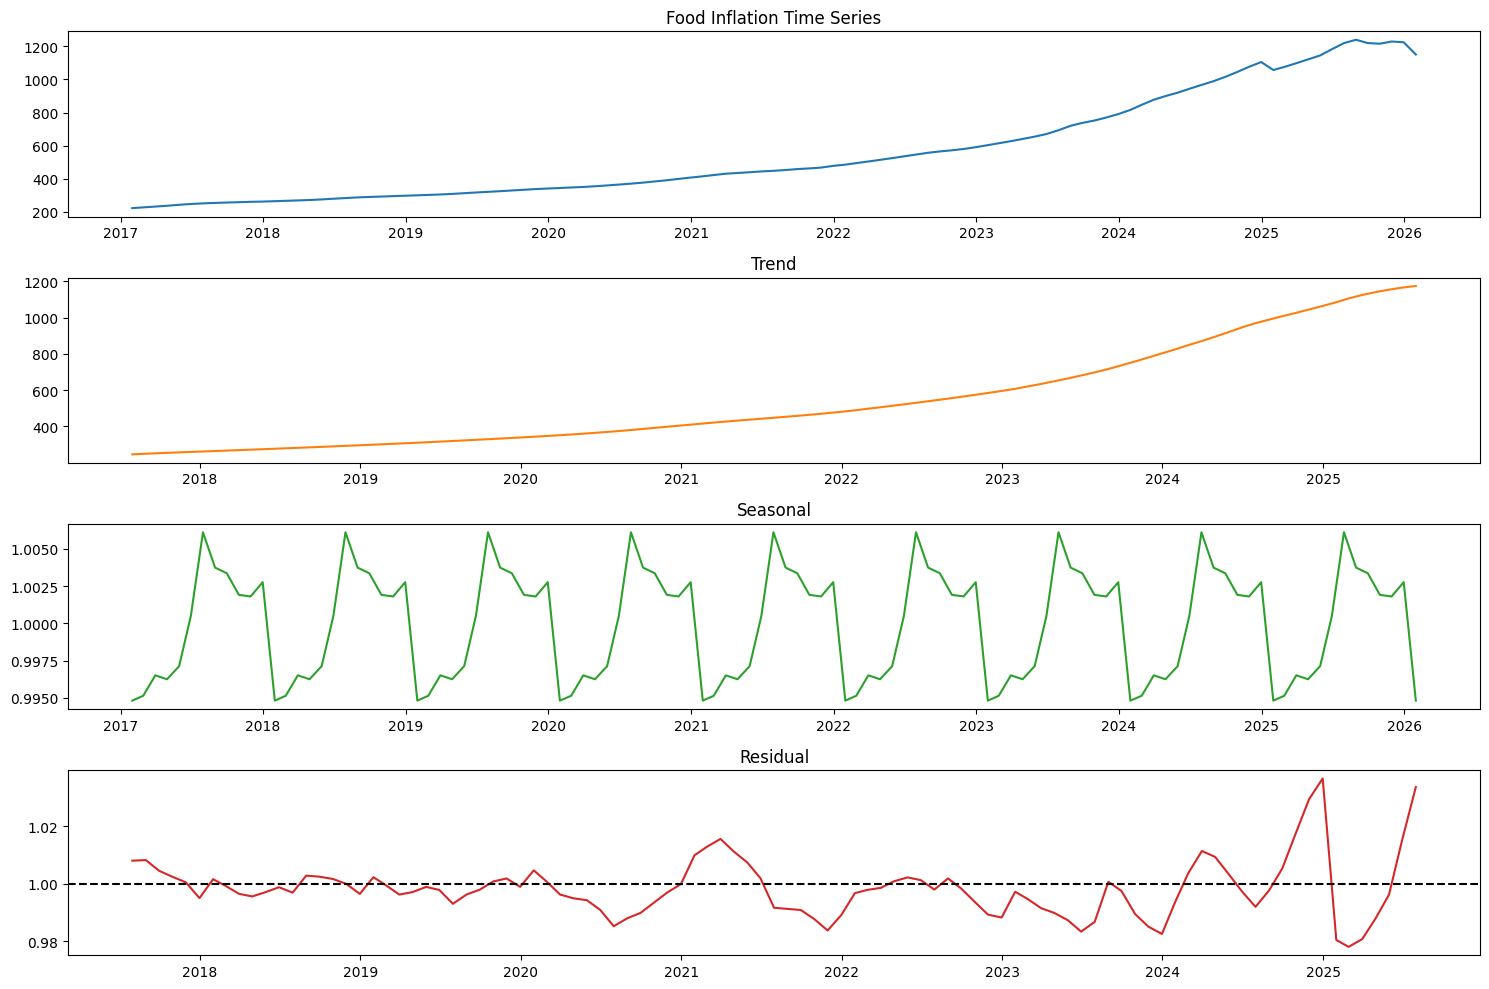

In [27]:
decompose_food = seasonal_decompose(df["food_cpi"], model="mul", period=12)
trend = decompose_food.trend
seasonal = decompose_food.seasonal
residual = decompose_food.resid

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

axes[0].plot(df["food_cpi"])
axes[0].set_title("Food Inflation Time Series")

axes[1].plot(trend, color="C1")
axes[1].set_title("Trend")

axes[2].plot(seasonal, color="C2")
axes[2].set_title("Seasonal")

axes[3].plot(residual, color="C3")
axes[3].set_title("Residual")
plt.axhline(1.0, linestyle="--", color="k")

plt.tight_layout()
plt.savefig('food_cpi_seasonal_decompose', dpi=150, bbox_inches='tight')
plt.show()

### Comparative Summary — Basket Cost vs Food CPI Decomposition

| Component | Basket Cost | Food CPI |
|---|---|---|
| **Trend shape** | Flat 2017–2020, exponential post-2023 | Continuously growing, steepening from 2022 |
| **Seasonal amplitude** | ±1.0% (moderate) | ±0.5% (very weak) |
| **Seasonal stability** | Consistent across full period | Consistent across full period |
| **Residual pre-shock** | Tight (0.95–1.05) | Very tight (0.98–1.02) |
| **Residual post-shock** | Volatile (0.93–1.06) | Highly volatile (0.97–1.08) |
| **Key implication** | Seasonal differencing warranted (D=1 or D=2) | Seasonal differencing not needed (D=0) |
| **GARCH justified?** | Yes — residual variance increases post-2023 | Yes — residual variance increases post-2024 |

In [6]:
adf_basket = adfuller(df["basket_cost"].dropna())
print(f"ADF Statistic P_value: {adf_basket[1]:.4f}")

ADF Statistic P_value: 0.8000


In [7]:
adf_food = adfuller(df["food_cpi"].dropna())
print(f"ADF Statistic P_value: {adf_food[1]:.4f}")

ADF Statistic P_value: 0.8183


In [8]:
from pmdarima.arima.utils import ndiffs

In [9]:
ndiffs(df["basket_cost"], test='adf')

2

In [10]:
ndiffs(df["food_cpi"], test='adf')

2

In [42]:
basket_diff = df["basket_cost"].diff().diff().dropna()

In [43]:
adf_basket = adfuller(basket_diff.dropna())
print(f"ADF Statistic P_value: {adf_basket[1]:.4f}")

ADF Statistic P_value: 0.1087


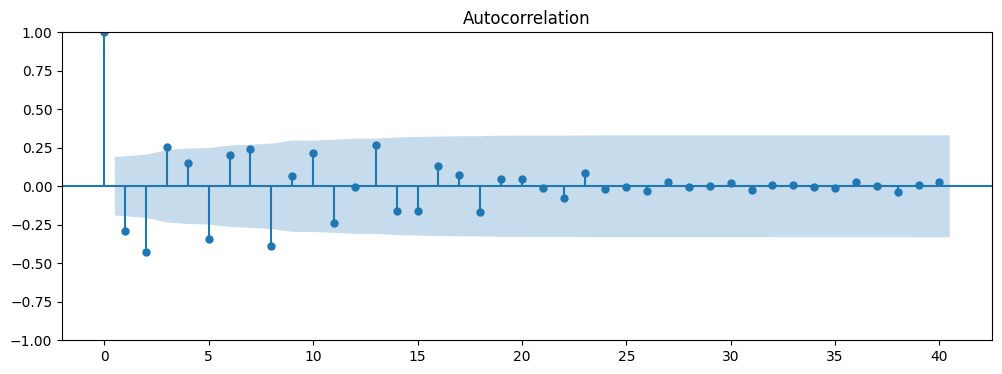

In [50]:
fig, ax =plt.subplots(figsize=(12, 4))
plot_acf(basket_diff, lags=40, ax=ax)
plt.savefig("basket_acf", dpi=150, bbox_inches='tight')
plt.show()

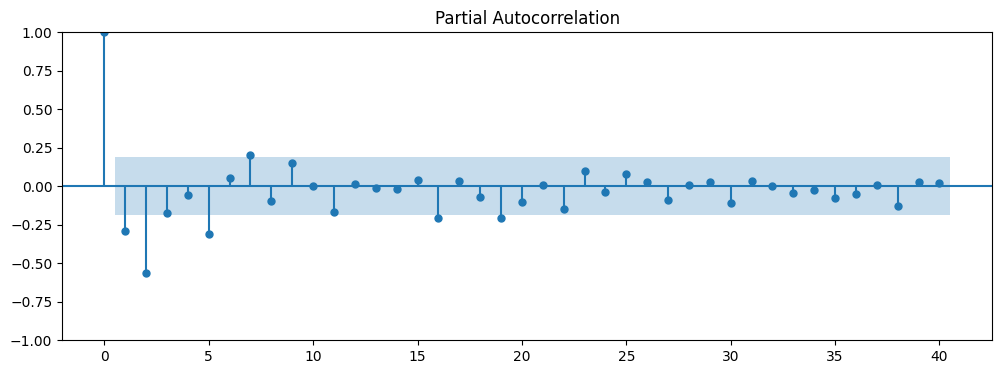

In [51]:
fig, ax =plt.subplots(figsize=(12, 4))
plot_pacf(basket_diff, lags=40, ax=ax)
plt.savefig("basket_pacf", dpi=150, bbox_inches='tight')
plt.show()